In [ ]:
! pip install facenet-pytorch

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 117.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 120.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 122.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 116.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 121.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 127.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 46.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 122.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import os

from PIL import Image

workers = 0 if os.name == 'nt' else 4

/home/iain/facial-recognition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Running on device: {}'.format(device))

Running on device: cuda:0


In [3]:
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [6]:
mtcnn = MTCNN(keep_all=True)

help(MTCNN)

Help on class MTCNN in module facenet_pytorch.models.mtcnn:

class MTCNN(torch.nn.modules.module.Module)
 |  MTCNN(image_size=160, margin=0, min_face_size=20, thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True, select_largest=True, selection_method=None, keep_all=False, device=None)
 |  
 |  MTCNN face detection module.
 |  
 |  This class loads pretrained P-, R-, and O-nets and returns images cropped to include the face
 |  only, given raw input images of one of the following types:
 |      - PIL image or list of PIL images
 |      - numpy.ndarray (uint8) representing either a single image (3D) or a batch of images (4D).
 |  Cropped faces can optionally be saved to file
 |  also.
 |  
 |  Keyword Arguments:
 |      image_size {int} -- Output image size in pixels. The image will be square. (default: {160})
 |      margin {int} -- Margin to add to bounding box, in terms of pixels in the final image. 
 |          Note that the application of the margin differs slightly from the 

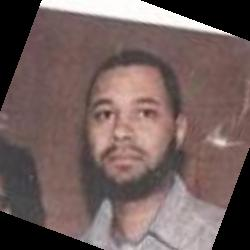

In [5]:
img = Image.open("/home/iain/facial-recognition/data/lfw-deepfunneled/Aaron_Patterson/Aaron_Patterson_0001.jpg")
img.show()

[0.9995723366737366]


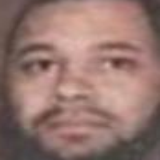

In [7]:
img_cropped, prob = mtcnn(img, return_prob=True)

print(prob)

denormalize = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])
tensor = denormalize(img_cropped.squeeze())

# Step 2: Clamp values to be within [0, 1]
tensor = torch.clamp(tensor, 0, 1)

# Step 3: Convert tensor to PIL Image
transform = transforms.ToPILImage()
image = transform(tensor)

# Step 4: Display the image
image.show()

In [23]:
trans = transforms.Compose([
    np.float32,
    transforms.ToTensor(),
    fixed_image_standardization
])

standard_transformation = trans(img)

In [32]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class FixedStandardization(A.ImageOnlyTransform):
    def __init__(self, always_apply=True, p=1.0):
        super().__init__(always_apply=always_apply, p=p)

    def apply(self, image, **params):
        return (image.astype("float32") - 127.5) / 128.0

# Define Albumentations transform
a_trans = A.Compose([
    FixedStandardization(),  # now properly registered
    ToTensorV2(),
])

new_transformation = a_trans(image= np.array(img))

diff = torch.abs(standard_transformation - new_transformation['image'])
diff.sum()

/tmp/ipykernel_11876/2943715037.py:6: UserWarning: Argument 'always_apply' is not valid and will be ignored.
  super().__init__(always_apply=always_apply, p=p)


tensor(0.)

In [17]:
embeddings = resnet(img_cropped.to(device) ).detach().cpu()
embeddings.shape

torch.Size([1, 512])

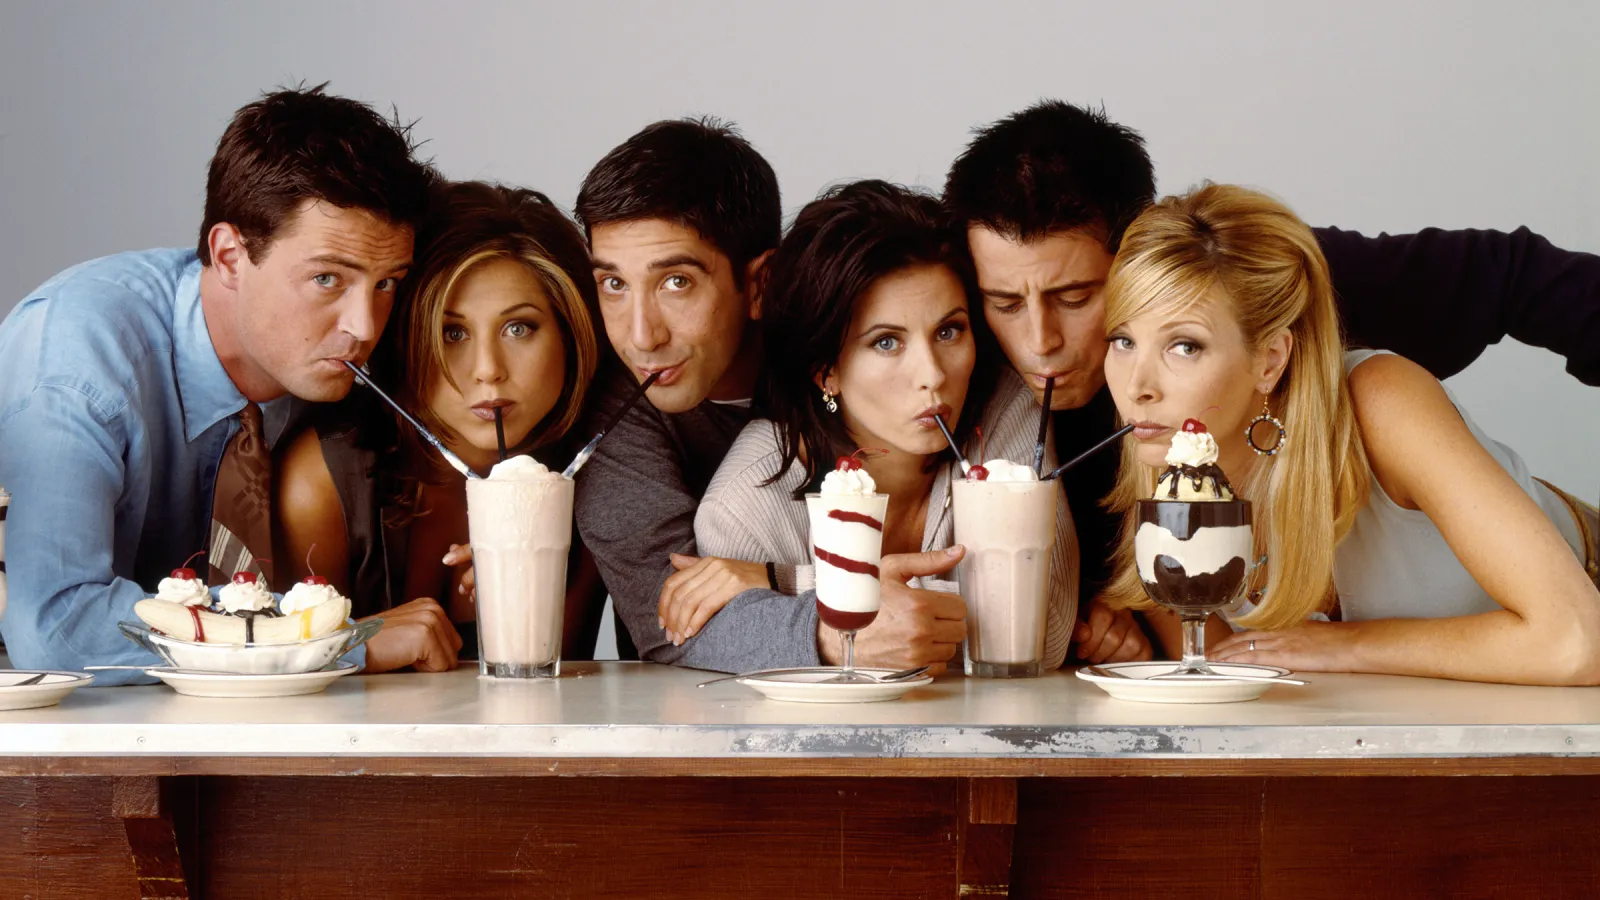

In [9]:
img = Image.open("RS-friends-cover-story.jpg")
img.show()

In [10]:
faces, prob = mtcnn(img, return_prob=True)
print(faces.shape)
print(prob)

torch.Size([6, 3, 160, 160])
[0.9998830556869507 0.9998600482940674 0.9983634352684021
 0.9997543692588806 0.9945998191833496 0.9992202520370483]


Displaying face 1...


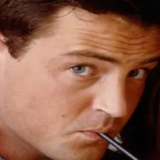

Displaying face 2...


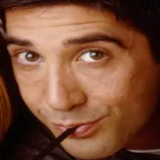

Displaying face 3...


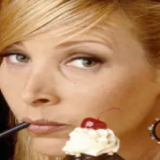

Displaying face 4...


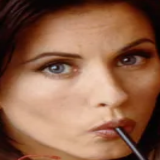

Displaying face 5...


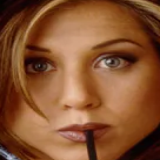

Displaying face 6...


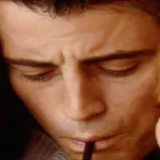

In [11]:
def display_image(tensor_image):
    # Step 1: Denormalize the image (if normalized between [-1, 1])
    denormalize = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])  # Adjust as needed
    tensor_image = denormalize(tensor_image)

    # Step 2: Clamp to [0, 1] range
    tensor_image = torch.clamp(tensor_image, 0, 1)

    # Step 3: Convert to PIL image
    transform = transforms.ToPILImage()
    image = transform(tensor_image)

    # Step 4: Display the image
    image.show()

# Iterate through the batch and display each image
for i in range(faces.shape[0]):  # batch.shape[0] gives the number of images (6)
    print(f"Displaying face {i+1}...")
    display_image(faces[i])

In [12]:
embeddings = resnet(faces.to(device) ).detach().cpu()
embeddings.shape

torch.Size([6, 512])

Brainstorming artificial data generation
- blur
- mirror flip
- distance
- greyscale
- edges
- age?
- angles? profiles?
combo of all for a factor of 7 

Displaying face 1


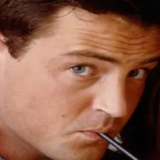

Displaying face 2


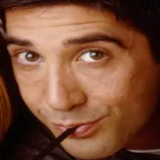

Displaying face 3


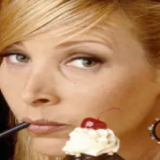

Displaying face 4


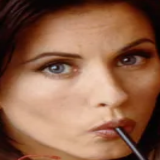

Displaying face 5


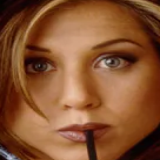

Displaying face 6


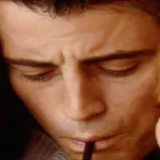

In [22]:
from torchvision import transforms
import torch

def get_and_show_pil_faces(tensor_batch):
    """
    Denormalizes a batch of face tensors, converts each to PIL,
    stores them in a list, and shows them.
    """
    denormalize = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])
    to_pil = transforms.ToPILImage()
    pil_images = []

    for i in range(tensor_batch.shape[0]):
        # Denormalize and clamp
        img = denormalize(tensor_batch[i])
        img = torch.clamp(img, 0, 1)
        
        # Convert to PIL and store
        pil_img = to_pil(img)
        pil_images.append(pil_img)
        
        # Display
        print(f"Displaying face {i+1}")
        pil_img.show()

    return pil_images

# Run it
pil_faces = get_and_show_pil_faces(faces)



Using Albumentations to Test Modify Faces

Face 1 - Augmentation 1


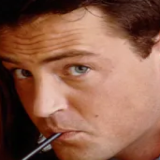

Face 1 - Augmentation 2


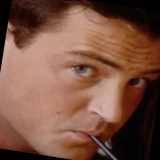

Face 1 - Augmentation 3


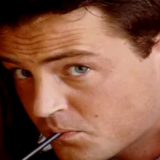

Face 1 - Augmentation 4


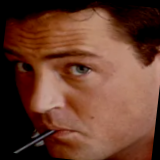

Face 1 - Augmentation 5


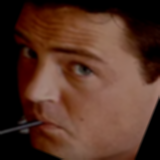

Face 2 - Augmentation 1


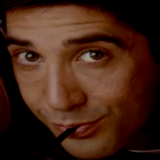

Face 2 - Augmentation 2


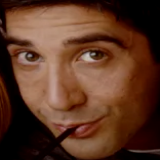

Face 2 - Augmentation 3


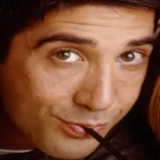

Face 2 - Augmentation 4


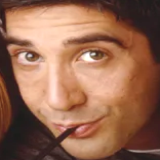

Face 2 - Augmentation 5


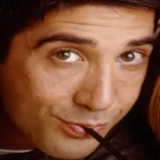

Face 3 - Augmentation 1


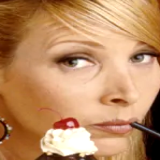

Face 3 - Augmentation 2


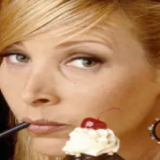

Face 3 - Augmentation 3


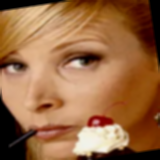

Face 3 - Augmentation 4


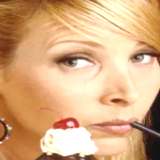

Face 3 - Augmentation 5


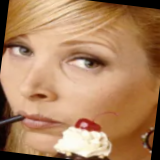

Face 4 - Augmentation 1


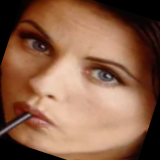

Face 4 - Augmentation 2


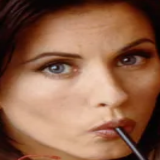

Face 4 - Augmentation 3


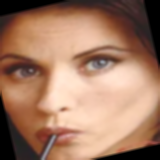

Face 4 - Augmentation 4


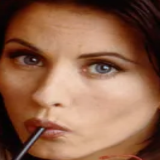

Face 4 - Augmentation 5


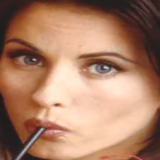

Face 5 - Augmentation 1


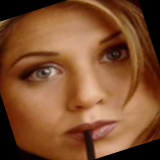

Face 5 - Augmentation 2


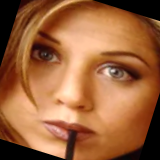

Face 5 - Augmentation 3


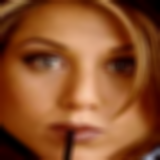

Face 5 - Augmentation 4


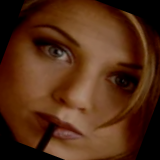

Face 5 - Augmentation 5


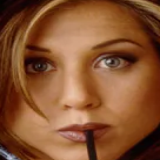

Face 6 - Augmentation 1


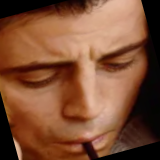

Face 6 - Augmentation 2


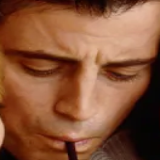

Face 6 - Augmentation 3


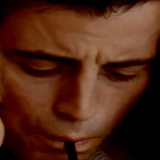

Face 6 - Augmentation 4


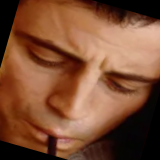

Face 6 - Augmentation 5


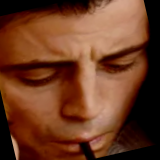

In [25]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image

# Augmentation pipeline (can add more)
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Rotate(limit=25, p=0.4),
    A.Blur(p=0.2),
    A.Resize(160, 160),  # keep all same size for model
])

# How many variations you want per face
n_variations = 5

# This will store all results
augmented_faces = []

# Iterate through each cropped face
for face_idx, pil_img in enumerate(pil_faces):
    np_img = np.array(pil_img)

    for aug_idx in range(n_variations):
        augmented = augmentation(image=np_img)["image"]
        augmented_faces.append(augmented)

        # Optional: show augmented result
        print(f"Face {face_idx+1} - Augmentation {aug_idx+1}")
        Image.fromarray(augmented).show()



In [27]:
from facenet_pytorch import MTCNN
from PIL import Image

mtcnn = MTCNN(keep_all=True, device=device)

# Load image
image_path = 'RS-friends-cover-story.jpg'
image = Image.open(image_path)

# Detect and crop all faces
faces, _ = mtcnn(image, return_prob=True)


In [28]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-058gnfjm
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-058gnfjm
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=e8f69bebb927aea9ffa749ebd6c5eafc2897a7b08fba26880e46e3280657d339
  Stored in directory: /tmp/pip-ephem-wheel-cache-vm66x_4k/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [clip]
Note: you may need to restart the kernel to use updated packages.


In [29]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


100%|███████████████████████████████████████| 338M/338M [05:01<00:00, 1.17MiB/s]


In [31]:
clip_embeddings = []

for i, face_tensor in enumerate(faces):
    # Convert Tensor to PIL, then to CLIP input
    face_pil = transforms.ToPILImage()(face_tensor)
    face_clip_input = preprocess(face_pil).unsqueeze(0).to(device)

    # Get CLIP embedding
    with torch.no_grad():
        embedding = model.encode_image(face_clip_input)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)  # Normalize

    clip_embeddings.append(embedding.cpu())

print(f"Extracted {len(clip_embeddings)} CLIP face embeddings.")


Extracted 6 CLIP face embeddings.
